In [2]:
import scanpy as sc
import pandas as pd
import numpy as np

In [3]:
pwd

'/ictstr01/groups/ml01/workspace/hpca/code'

In [4]:
ts_remapped = sc.read_h5ad('../data/datasets/Tabula_Sapiens/Tabula_Sapiens_GeneFull_filtered_concat.h5ad')

In [6]:
ts_czi = sc.read_h5ad('../data/datasets/Tabula_Sapiens/TS_CZI.h5ad')

In [8]:
ts_czi

AnnData object with n_obs × n_vars = 14140 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tiss

In [7]:
ts_remapped

AnnData object with n_obs × n_vars = 34299 × 36601
    obs: 'ID', 'Dataset'
    layers: 'raw'

In [9]:
ts_czi.obs['barcode'] = ts_czi.obs_names.str.split('_').str[-1]

In [10]:
ts_czi.obs.head()

,donor_id,tissue_in_publication,anatomical_position,method,cdna_plate,library_plate,notes,cdna_well,assay_ontology_term_id,sample_id,...,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,barcode
TSP1_Pancreas_Exocrine_10X3primev31_2_2_AAACGAACACTTTATC,TSP1,Pancreas,Exocrine,10X,nan,nan,None,nan,EFO:0009922,TSP1_Pancreas_Exocrine_10X3primev31_2_2,...,pancreatic acinar cell,10x 3' v3,normal,Homo sapiens,female,exocrine pancreas,European,59-year-old stage,SM<dqT4ZNm,AAACGAACACTTTATC
TSP1_Pancreas_Exocrine_10X3primev31_2_2_AAACGAACAGCCGTTG,TSP1,Pancreas,Exocrine,10X,nan,nan,None,nan,EFO:0009922,TSP1_Pancreas_Exocrine_10X3primev31_2_2,...,pancreatic ductal cell,10x 3' v3,normal,Homo sapiens,female,exocrine pancreas,European,59-year-old stage,33N~Yw&1|0,AAACGAACAGCCGTTG
TSP1_Pancreas_Exocrine_10X3primev31_2_2_AAACGAATCGATGCTA,TSP1,Pancreas,Exocrine,10X,nan,nan,None,nan,EFO:0009922,TSP1_Pancreas_Exocrine_10X3primev31_2_2,...,pancreatic ductal cell,10x 3' v3,normal,Homo sapiens,female,exocrine pancreas,European,59-year-old stage,>~p}nz~*SU,AAACGAATCGATGCTA
TSP1_Pancreas_Exocrine_10X3primev31_2_2_AAACGCTAGGGTCAAC,TSP1,Pancreas,Exocrine,10X,nan,nan,None,nan,EFO:0009922,TSP1_Pancreas_Exocrine_10X3primev31_2_2,...,pancreatic ductal cell,10x 3' v3,normal,Homo sapiens,female,exocrine pancreas,European,59-year-old stage,Z|r9oN!S^@,AAACGCTAGGGTCAAC
TSP1_Pancreas_Exocrine_10X3primev31_2_2_AAAGAACGTCATCCCT,TSP1,Pancreas,Exocrine,10X,nan,nan,None,nan,EFO:0009922,TSP1_Pancreas_Exocrine_10X3primev31_2_2,...,pancreatic acinar cell,10x 3' v3,normal,Homo sapiens,female,exocrine pancreas,European,59-year-old stage,*{~bB2CyyZ,AAAGAACGTCATCCCT


In [12]:
ts_remapped.obs.head()

,ID,Dataset
barcode,,
AAACCCAAGACATCAA,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCAAGCGCCGTT,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCAAGGGCAATC,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCAAGTGATAAC,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCACAATTCACG,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens


In [13]:
ts_czi_barcodes = set(ts_czi.obs_names.str.split('_').str[-1])
adata_barcodes = set(ts_remapped.obs_names)

In [207]:
# dict(zip(ts_czi.obs.barcode, ts_czi.obs.cell_type))

In [14]:
ts_remapped.obs['Author_Annotation'] = ts_remapped.obs_names.map(dict(zip(ts_czi.obs.barcode, ts_czi.obs.cell_type)))

In [15]:
ts_remapped.obs[~ts_remapped.obs.Author_Annotation.isna()]

,ID,Dataset,Author_Annotation
barcode,,,
AAACCCACACCCTGTT,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,macrophage
AAACCCACAGCTATTG,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,pancreatic acinar cell
AAACCCAGTCGGTAAG,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,pancreatic ductal cell
AAACCCAGTCGTATGT,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,"CD8-positive, alpha-beta T cell"
AAACCCAGTCTGGTTA,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,endothelial cell
...,...,...,...
TTTGACTCATATACCG,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens,pancreatic ductal cell
TTTGATCCAGGCTTGC,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens,pancreatic ductal cell
TTTGGAGAGGAGACCT,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens,pancreatic ductal cell


In [18]:
new_obs = pd.read_csv('../data/26_02_2025_obs.csv')

/tmp/ipykernel_909773/3428291137.py:1: DtypeWarning: Columns (3,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,37,38,39,40,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  new_obs = pd.read_csv('../data/26_02_2025_obs.csv')


In [23]:
new_obs.head()

,barcode,Dataset,ID,Manual_Annotation,Level_1_Harmonized,celltype_all,sample_id,donor_id,institute,library_id,...,pct_counts_mito,GSE84133_Annotation,GSE183568_Annotation,GSE198623_Annotation,HPAP_Annotation,charite_snRNA_Annotation,espace_Annotation,Author_Annotation,Cell_Annotation_Merged,Cell_Type_Harmonized
0,DBHQ_hig_AAACGCTCACTGGAAG-1_DBHQ,espace_scRNA_cultured_islets,DBHQ_hig_Leiden_ND_organ-donor_55_29_53_M_hig_72,NaN,Endothelial Cells,Endothelial Cells,NaN,NaN,NaN,NaN,...,3.502288,NaN,NaN,NaN,NaN,NaN,Endothelial,Endothelial,Endothelial,Endothelial Cell
1,DBHQ_hig_AAGAACATCTCAACGA-1_DBHQ,espace_scRNA_cultured_islets,DBHQ_hig_Leiden_ND_organ-donor_55_29_53_M_hig_72,NaN,Endothelial Cells,Endothelial Cells,NaN,NaN,NaN,NaN,...,4.231231,NaN,NaN,NaN,NaN,NaN,Endothelial,Endothelial,Endothelial,Endothelial Cell
2,DBHQ_hig_AATGGCTAGGCTTCCG-1_DBHQ,espace_scRNA_cultured_islets,DBHQ_hig_Leiden_ND_organ-donor_55_29_53_M_hig_72,NaN,Endothelial Cells,Endothelial Cells,NaN,NaN,NaN,NaN,...,11.996180,NaN,NaN,NaN,NaN,NaN,Endothelial,Endothelial,Endothelial,Endothelial Cell
3,DBHQ_hig_ACATCCCGTTAATCGC-1_DBHQ,espace_scRNA_cultured_islets,DBHQ_hig_Leiden_ND_organ-donor_55_29_53_M_hig_72,NaN,Endothelial Cells,Endothelial Cells,NaN,NaN,NaN,NaN,...,2.658706,NaN,NaN,NaN,NaN,NaN,Endothelial,Endothelial,Endothelial,Endothelial Cell
4,DBHQ_hig_ACATCGAGTCCACTCT-1_DBHQ,espace_scRNA_cultured_islets,DBHQ_hig_Leiden_ND_organ-donor_55_29_53_M_hig_72,NaN,Endothelial Cells,Endothelial Cells,NaN,NaN,NaN,NaN,...,2.900447,NaN,NaN,NaN,NaN,NaN,Endothelial,Endothelial,Endothelial,Endothelial Cell


In [30]:
new_obs.Cell_Type_Harmonized.unique()

array(['Endothelial Cell', 'Acinar Cell', 'Ductal Cell', 'Alpha Cell',
       'Beta Cell', 'Pancreatic Polypeptide Cell', 'Delta Cell',
       'Epsilon Cell', 'T Cell', 'Macrophage Cell', 'Schwann Cell',
       'Stellate Cell', 'Immune Cell', 'Mast Cell', 'Fibroblast Cell',
       'B Cell', 'Adipocyte Cell', 'Gamma + Epsilon Cell',
       'Alpha + Beta Cell', nan, 'Neuronal Cell', 'Neuroendocrine Cell'],
      dtype=object)

In [24]:
ts_remapped.obs['barcode_ID'] = ts_remapped.obs_names + '_' + ts_remapped.obs['ID'].astype(str)
# new_obs['barcode_ID'] = ts_remapped.obs_names + '_' + ts_remapped.obs['ID'].astype(str)
dict_map = dict(zip(new_obs[new_obs.Dataset == 'Tabula_Sapiens'].barcode, new_obs[new_obs.Dataset == 'Tabula_Sapiens'].Manual_Annotation))
ts_remapped.obs['Manual_Annotation'] = ts_remapped.obs.barcode_ID.map(dict_map)

In [26]:
ts_remapped_matched = ts_remapped[~ts_remapped.obs.Author_Annotation.isna()]

In [37]:
ts_remapped_matched.obs.Author_Annotation.unique()

array(['macrophage', 'pancreatic acinar cell', 'pancreatic ductal cell',
       'CD8-positive, alpha-beta T cell', 'endothelial cell',
       'classical monocyte', 'pancreatic stellate cell',
       'natural killer cell', 'fibroblast', 'B cell',
       'intermediate monocyte', 'CD4-positive, alpha-beta T cell',
       'plasma cell', 'type B pancreatic cell', 'neutrophil', 'T cell',
       'monocyte', 'non-classical monocyte', 'pancreatic D cell',
       'pancreatic A cell', 'mast cell', 'mature NK T cell',
       'pancreatic PP cell'], dtype=object)

In [29]:
ts_remapped_matched.obs.Manual_Annotation.unique()

array(['Macrophage', 'Acinar Cell', 'Endothelial Cell',
       'Activated Stellate Cell', 'Endothelial Cells', 'Ductal Cell',
       'Acitvated Stellate Cell', nan, 'Beta Cell'], dtype=object)

In [38]:
harmonized_mapping = {
    "macrophage": "Macrophage",
    "pancreatic acinar cell": "Acinar Cell",
    "pancreatic ductal cell": "Ductal Cell",
    "CD8-positive, alpha-beta T cell": "T Cell",
    "endothelial cell": "Endothelial Cell",
    "classical monocyte": "Monocyte",  # Classical monocytes are macrophage precursors
    "pancreatic stellate cell": "Stellate Cell",
    "natural killer cell": "Natural Killer Cell",  # NK cells belong to innate immunity
    "fibroblast": "Fibroblast",
    "B cell": "B Cell",
    "intermediate monocyte": "Monocyte",
    "CD4-positive, alpha-beta T cell": "T Cell",
    "plasma cell": "B Cell",  # Plasma cells are differentiated B cells
    "type B pancreatic cell": "Beta Cell",
    "neutrophil": "Neutrophil",
    "T cell": "T Cell",
    "monocyte": "Monocyte",
    "non-classical monocyte": "Monocyte",
    "pancreatic D cell": "Delta Cell",
    "pancreatic A cell": "Alpha Cell",
    "mast cell": "Mast Cell",
    "mature NK T cell": "T Cell",  # NK T cells are a subtype of T cells
    "pancreatic PP cell": "Pancreatic Polypeptide Cell"
}

In [40]:
ts_remapped_matched.obs['Author_Annotation_Harmonized'] = ts_remapped_matched.obs.Author_Annotation.map(harmonized_mapping)

/tmp/ipykernel_909773/1558715460.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ts_remapped_matched.obs['Author_Annotation_Harmonized'] = ts_remapped_matched.obs.Author_Annotation.map(harmonized_mapping)


In [43]:
ts_remapped_matched.obs[ts_remapped_matched.obs.Manual_Annotation != ts_remapped_matched.obs.Author_Annotation_Harmonized]

,ID,Dataset,Author_Annotation,barcode_ID,Manual_Annotation,Author_Annotation_Harmonized
barcode,,,,,,
AAACCCAGTCGGTAAG,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,pancreatic ductal cell,AAACCCAGTCGGTAAG_TSP9_Pancreas_exocrine_10X_1_...,Acinar Cell,Ductal Cell
AAACCCAGTCGTATGT,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,"CD8-positive, alpha-beta T cell",AAACCCAGTCGTATGT_TSP9_Pancreas_exocrine_10X_1_...,Endothelial Cell,T Cell
AAACCCAGTCTGGTTA,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,endothelial cell,AAACCCAGTCTGGTTA_TSP9_Pancreas_exocrine_10X_1_...,Acinar Cell,Endothelial Cell
AAACCCATCGGCATAT,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,endothelial cell,AAACCCATCGGCATAT_TSP9_Pancreas_exocrine_10X_1_...,Acinar Cell,Endothelial Cell
AAACGAACAATAACGA,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens,macrophage,AAACGAACAATAACGA_TSP9_Pancreas_exocrine_10X_1_...,Activated Stellate Cell,Macrophage
...,...,...,...,...,...,...
TTGTTGTGTGGATACG,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens,pancreatic ductal cell,TTGTTGTGTGGATACG_TSP1_endopancreas_3_GeneFull_...,Acinar Cell,Ductal Cell
TTGTTTGTCATGGTAC,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens,pancreatic ductal cell,TTGTTTGTCATGGTAC_TSP1_endopancreas_3_GeneFull_...,Acinar Cell,Ductal Cell
TTTATGCGTTTCACAG,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens,pancreatic ductal cell,TTTATGCGTTTCACAG_TSP1_endopancreas_3_GeneFull_...,Acinar Cell,Ductal Cell


In [48]:
ts_remapped_matched.obs.rename(columns={'Author_Annotation_Harmonized': 'Cell_Type_Harmonized'}, inplace=True)

In [50]:
ts_remapped_matched.obs.drop('Manual_Annotation', axis=1, inplace=True)

In [ ]:
ts_remapped_matched

In [51]:
ts_remapped_matched.write('../data/datasets/Tabula_Sapiens/Tabula_Sapiens_Matched_Author_Annotation_concat.h5ad')

### transferred labels for TS from CZI to remapped from Sanger

# GSE84133

In [7]:
adata_84133.obs_names = adata_84133.obs_names.str.replace('_', '-')
adata_84133.obs.index = adata_84133.obs.index.str.replace('_', '-')

# load the obs

In [41]:
file_paths = [
    '/Users/shrey.parikh/Desktop/HPCA/Datasets/GSE84133_RAW/GSM2230757_human1_umifm_counts.csv',
    '/Users/shrey.parikh/Desktop/HPCA/Datasets/GSE84133_RAW/GSM2230758_human2_umifm_counts.csv',
    '/Users/shrey.parikh/Desktop/HPCA/Datasets/GSE84133_RAW/GSM2230759_human3_umifm_counts.csv',
    '/Users/shrey.parikh/Desktop/HPCA/Datasets/GSE84133_RAW/GSM2230760_human4_umifm_counts.csv'
]
combined_dict = {}
adata_84133.obs['cell_type'] = 'unknown'
for file in file_paths:
    df = pd.read_csv(file, usecols=['barcode', 'assigned_cluster'])
    # print(df)
    cell_type_map = dict(zip(df['barcode'], df['assigned_cluster']))
    combined_dict.update(cell_type_map)
    adata_84133.obs['cell_type'] = pd.Series(adata_84133.obs.index.map(cell_type_map),index=adata_84133.obs.index).fillna(adata_84133.obs['cell_type'])

In [42]:
pd.DataFrame.from_dict(combined_dict, orient='index').to_csv('../Datasets/GSE84133_annot_df.csv')

In [43]:
combined_dict = pd.DataFrame.from_dict(combined_dict, orient='index')

In [45]:
combined_dict.reset_index(inplace=True)

In [46]:

# combined_dict = pd.read_csv('../Datasets/GSE84133_annot_df.csv')
combined_dict.columns = ['barcode', 'cell_type']

In [47]:
combined_dict

,barcode,cell_type
0,GATGACGGAC-GGTGGGAT,acinar
1,GAGCGTTGCT-ACCTTCTT,acinar
2,CTTACGGG-CCATTACT,acinar
3,GATGTACACG-TTAAACTG,acinar
4,GAGATTGCGA-GTCGTCGT,acinar
...,...,...
8282,GAGATCTCGG-GTCTCTCT,activated_stellate
8283,GCTTACCT-ATGTTGGC,alpha
8284,TGACACAGTTT-TTGTCGCC,beta
8285,GACGACTCCT-CGCTAATA,beta


In [48]:
len([i for i in combined_dict.barcode if i not in adata_84133.obs.index])

728

In [49]:
len([i for i in adata_84133.obs.index if i not in combined_dict.barcode])

10272

In [37]:
cell_type_map = dict(combined_dict.set_index('barcode')['cell_type'])
adata_84133.obs['CellTypes'] = adata_84133.obs_names.str.replace('_', '-').map(cell_type_map).fillna('unknown')

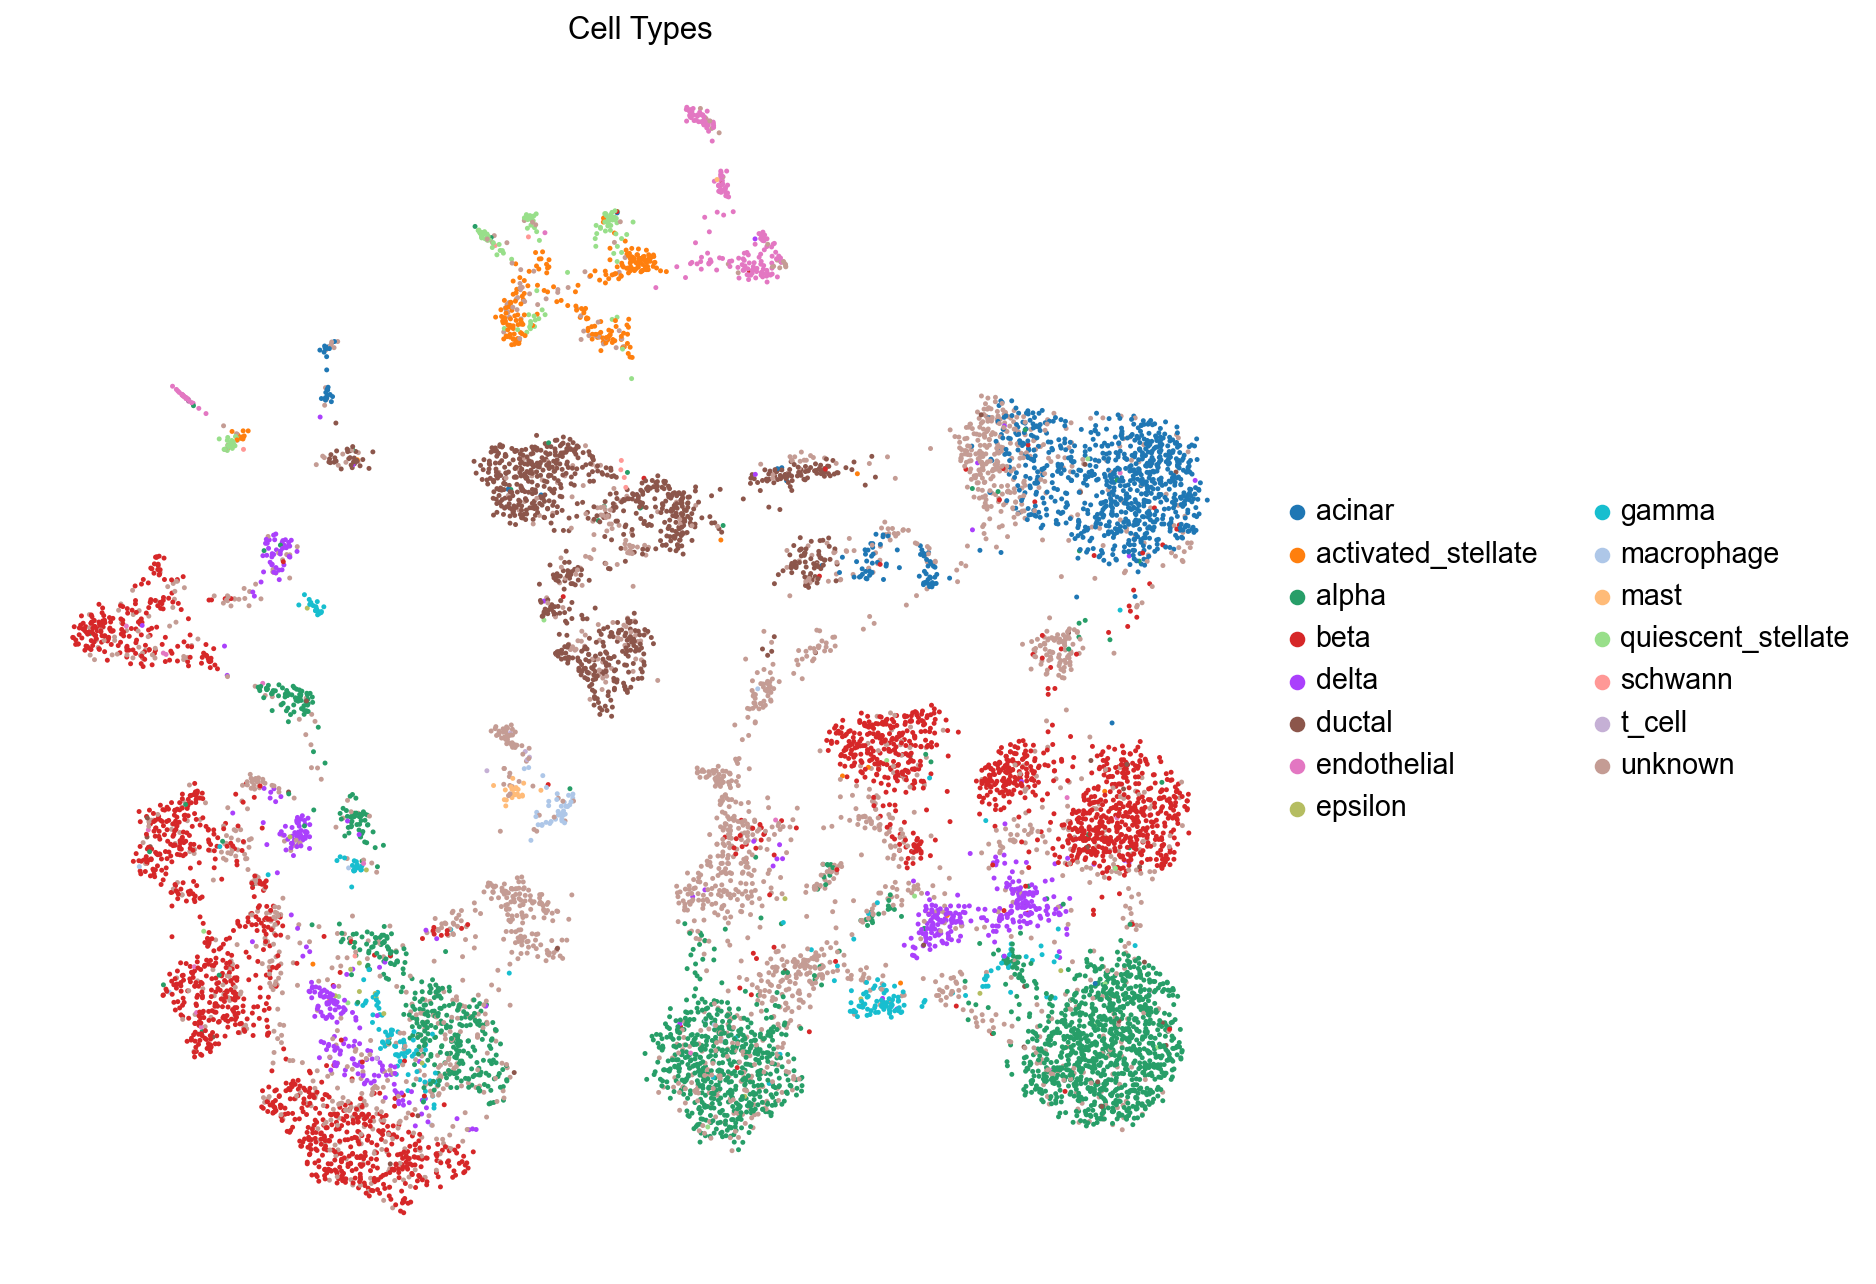

In [42]:
sc.pl.umap(adata_84133, color='cell_type', title='Cell Types', size=20)

In [52]:
print(adata_84133.shape)
# Some cells in the remapped adata are not present in the GEO downloaded dataset

(10272, 30158)


# Try to Resolve unknown cells

In [73]:
not_present = [i for i in combined_dict.barcode if i not in adata_84133.obs_names]
# only need adata subset from the GEO dataset

In [87]:
not_present[0]

'GATGACGGAC-GGTGGGAT'

In [ ]:
adata_84133[adata_84133.obs_names.str.contains('GGTGGGAT')].obs

,ID,Dataset,Leiden_05,Leiden_075,cell_type
barcode,,,,,
GGTGGGAT-AACACACG,GSM2230759_GeneFull_filtered,GSE84133_remapped,9,10,unknown
GGTGGGAT-AATTCCCA,GSM2230759_GeneFull_filtered,GSE84133_remapped,1,1,alpha
GGTGGGAT-TACAGCCG,GSM2230759_GeneFull_filtered,GSE84133_remapped,1,1,alpha
GGTGGGAT-TCTAGCAG,GSM2230759_GeneFull_filtered,GSE84133_remapped,1,1,alpha
GGTGGGAT-TGCTATTT,GSM2230759_GeneFull_filtered,GSE84133_remapped,2,2,ductal
GGTGGGAT-TGTCTTTC,GSM2230759_GeneFull_filtered,GSE84133_remapped,6,6,acinar
GGTGGGAT-CCATTACT,GSM2230757_GeneFull_filtered,GSE84133_remapped,18,23,alpha
GGTGGGAT-CTTAGGTA,GSM2230757_GeneFull_filtered,GSE84133_remapped,14,17,epsilon
GGTGGGAT-CTTCTTCG,GSM2230757_GeneFull_filtered,GSE84133_remapped,18,21,beta


In [84]:
# barcodes present in combined_dict are not present in adata at all

In [88]:
# Subset the adata to only include the barcodes present in the combined_dict

In [89]:
adata_84133_subset = adata_84133[adata_84133.obs_names.isin(combined_dict.barcode)]

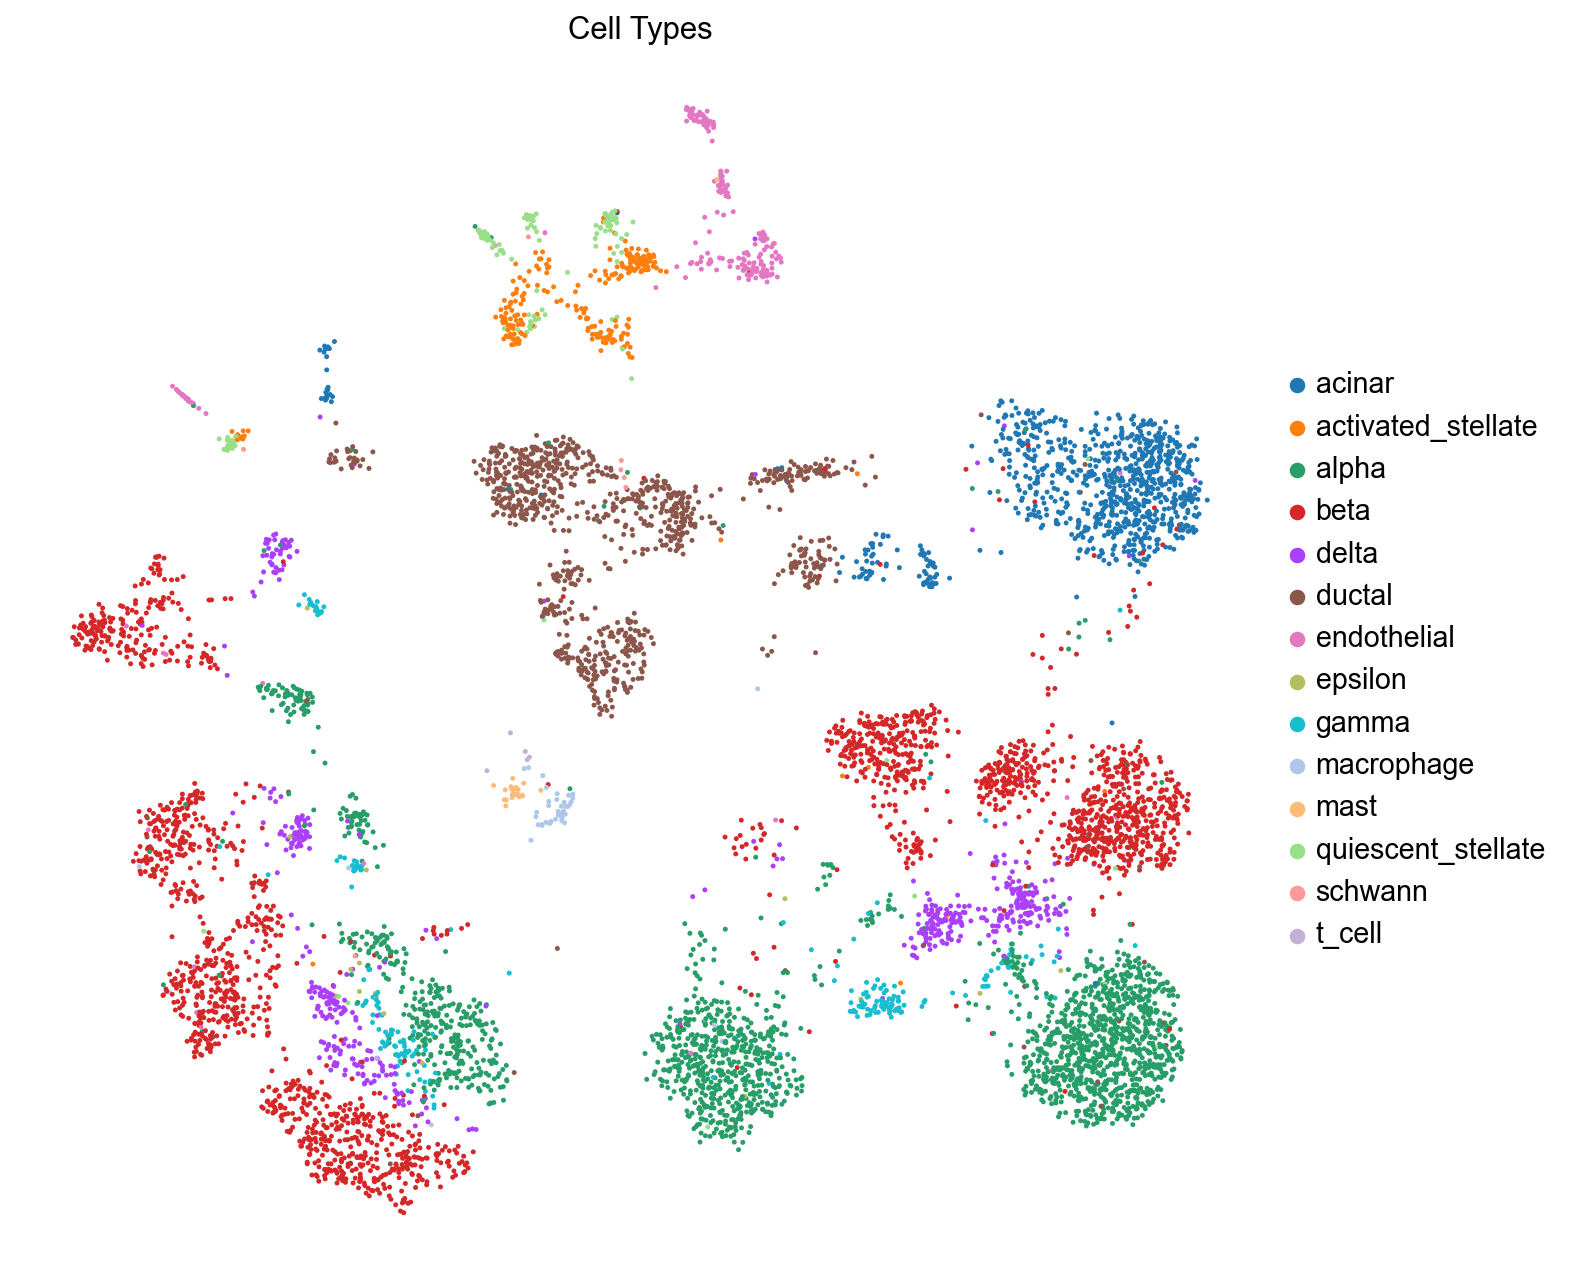

In [91]:
sc.pl.umap(adata_84133_subset, color='cell_type', title='Cell Types', size=20)

In [92]:
adata_84133_subset.obs['CellTypes'] = adata_84133_subset.obs.cell_type.copy()

In [96]:
adata_84133_subset

AnnData object with n_obs × n_vars = 7559 × 30158
    obs: 'ID', 'Dataset', 'Leiden_05', 'Leiden_075', 'cell_type', 'CellTypes'
    var: 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'Leiden_05', 'Leiden_075', 'rank_genes_groups', 'Leiden_075_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'distances', 'connectivities'

In [93]:
adata_84133_subset.write('../Datasets/GSE84133_remapped_human_annotated.h5ad')

In [94]:
adata_84133_subset.obs['cell_type'].value_counts()

beta                  2196
alpha                 2075
ductal                 973
acinar                 874
delta                  523
activated_stellate     252
gamma                  226
endothelial            203
quiescent_stellate     138
macrophage              46
mast                    22
epsilon                 16
schwann                  9
t_cell                   6
Name: cell_type, dtype: int64

### Transferred labels from GEO to remapped from Sanger